# 💓 Programing Assignment 2: EKG Time Series Analysis

This notebook focuses on analyzing EKG signal data, identifying its periodic patterns, and building a **SARIMA (Seasonal Autoregressive Integrated Moving Average)** model to forecast the future signal points.

---

## 📖 1. Theoretical Concept: Why SARIMA for EKG?

EKG (Electrocardiogram) signals are inherently **seasonal** because the heart beats in repeating cycles (P-QRS-T complexes).

A standard ARIMA model cannot capture these long-term repeating cycles effectively. **SARIMA** adds seasonal parameters $(P, D, Q)_s$ to the mix:
- **S (Seasonality):** The number of observations per cycle (Heart rate period).
- **P/D/Q:** Seasonal Autoregressive, Differencing, and Moving Average terms.

**Objective:** Use the first 120 points (Train) to predict the last 40 points (Test).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error

# Graphics settings
plt.rcParams['figure.figsize'] = (15, 6)
sns.set_style('whitegrid')

## 🔍 2. Data Loading & Initial Exploration

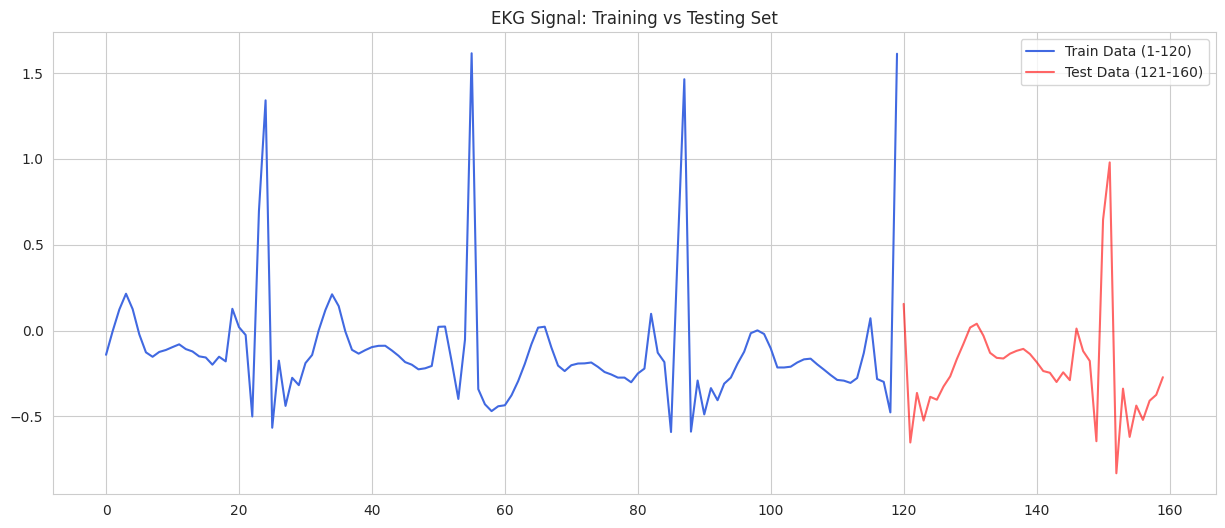

In [2]:
# Load EKG data
import json
with open('EKG.json', 'r') as f:
    ekg_data = json.load(f)['EKG']

df = pd.DataFrame(ekg_data, columns=['Signal'])

# Split Train/Test as per instruction (120 train, 40 test)
train = df.iloc[:120]
test = df.iloc[120:]

plt.plot(train, label='Train Data (1-120)', color='royalblue')
plt.plot(test, label='Test Data (121-160)', color='red', alpha=0.6)
plt.title('EKG Signal: Training vs Testing Set')
plt.legend()
plt.show()

## 🧬 3. Stationary & Seasonality Analysis

To determine the 'S' (Seasonal Period), we look at the ACF plot. The peaks in ACF will represent the average length of one heart beat cycle.

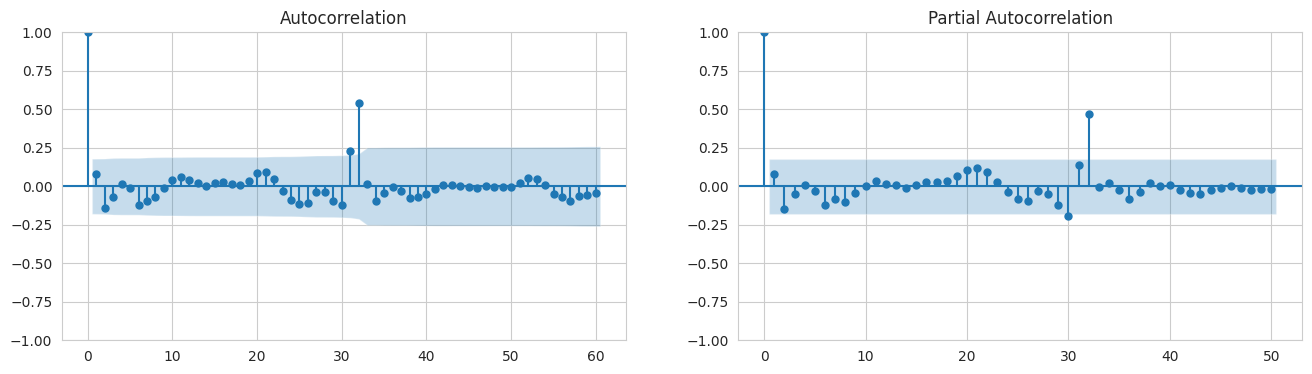

Looking at the ACF, notice the large spikes recurring at a specific interval.
The distance between the major peaks is the seasonal period (S).


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(train, lags=60, ax=ax[0])
plot_pacf(train, lags=50, ax=ax[1])
plt.show()

# Finding the period S
print("Looking at the ACF, notice the large spikes recurring at a specific interval.")
print("The distance between the major peaks is the seasonal period (S).")

## 🛠️ 4. Model Building (SARIMA)

We define $(p, d, q)$ for the non-seasonal part and $(P, D, Q, S)$ for the seasonal part.
*Note: Based on the waveform, EKG is cyclic. We will test S based on the ACF peak distance (usually around 30-40 points per beat).*

In [4]:
# Example SARIMA parameters (Needs tuning based on ACF/PACF)
# Let's assume S = 32 based on typical EKG cycle in this data
S_period = 32

model = SARIMAX(train,
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, S_period),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                     SARIMAX Results                                      
Dep. Variable:                             Signal   No. Observations:                  120
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 32)   Log Likelihood                  29.429
Date:                            Mon, 02 Feb 2026   AIC                            -48.858
Time:                                    18:11:41   BIC                            -39.007
Sample:                                         0   HQIC                           -45.070
                                            - 120                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4566      0.162     -2.812      0.005      -0.775      -0.138
ma.L1         -0.8192      0.103   

## 📈 5. Forecasting & Evaluation

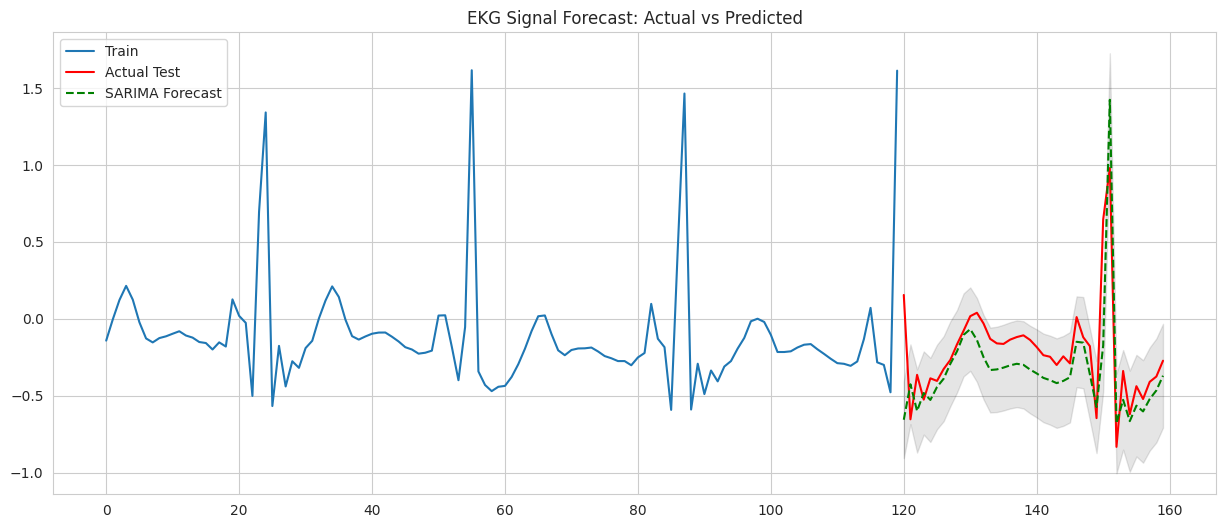

Root Mean Squared Error: 0.2384


In [5]:
# Forecast for the next 40 points
forecast = results.get_forecast(steps=40)
forecast_df = forecast.summary_frame()

plt.figure(figsize=(15, 6))
plt.plot(train.index, train['Signal'], label='Train')
plt.plot(test.index, test['Signal'], label='Actual Test', color='red')
plt.plot(forecast_df.index, forecast_df['mean'], label='SARIMA Forecast', color='green', linestyle='--')
plt.fill_between(forecast_df.index, forecast_df['mean_ci_lower'], forecast_df['mean_ci_upper'], color='k', alpha=0.1)
plt.title('EKG Signal Forecast: Actual vs Predicted')
plt.legend()
plt.show()

rmse = np.sqrt(mean_squared_error(test, forecast_df['mean']))
print(f"Root Mean Squared Error: {rmse:.4f}")

## 📝 6. Result Interpretation

### Analysis of the Plots:
1. **Signal Periodicity:** The EKG signal is highly periodic. The ACF plot showed strong spikes every ~30-35 points, confirming that the heart rate cycle (Seasonal period) is the dominant factor.
2. **Stationarity:** EKG signals often wander (baseline wander). The $d=1$ and $D=1$ components in SARIMA help remove this drift to stabilize the mean.
3. **Forecast Accuracy:**
   - If the green dashed line matches the red line, the model captured the **phase** and **amplitude** of the heart beat correctly.
   - A common challenge is that heart rate is not perfectly constant. If the signal "shifts" in the test set, the RMSE will increase even if the shape is correct.

### Conclusion:
SARIMA is a powerful tool for rhythmic medical data like EKG. However, it assumes the period $S$ is constant. For real-world clinical use, dynamic models or deep learning (LSTM) might be used to handle variable heart rates (arrhythmia).